In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import joblib

sns.set_style("whitegrid")

In [2]:
np.random.seed(42)

data_size = 200

Area = np.random.randint(500, 3000, data_size)
Bedrooms = np.random.randint(1, 5, data_size)
House_Age = np.random.randint(0, 30, data_size)
Distance = np.random.randint(1, 20, data_size)

Price = (
    Area * 0.03 +
    Bedrooms * 5 -
    House_Age * 0.7 -
    Distance * 1.5 +
    np.random.normal(0, 10, data_size)
)

df = pd.DataFrame({
    "Area": Area,
    "Bedrooms": Bedrooms,
    "House_Age": House_Age,
    "Distance": Distance,
    "Price": Price
})

df.head()

,Area,Bedrooms,House_Age,Distance,Price
0,1360,3,2,19,37.692972
1,1794,2,17,9,39.095185
2,1630,3,24,7,57.207479
3,1595,3,23,4,58.303408
4,2138,3,12,18,41.250359


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       200 non-null    int32  
 1   Bedrooms   200 non-null    int32  
 2   House_Age  200 non-null    int32  
 3   Distance   200 non-null    int32  
 4   Price      200 non-null    float64
dtypes: float64(1), int32(4)
memory usage: 4.8 KB
None
              Area   Bedrooms   House_Age    Distance       Price
count   200.000000  200.00000  200.000000  200.000000  200.000000
mean   1793.225000    2.60000   15.345000   10.120000   40.377472
std     679.916795    1.15615    9.159995    5.529782   26.627573
min     501.000000    1.00000    0.000000    1.000000  -24.218919
25%    1259.000000    2.00000    7.000000    5.000000   21.094086
50%    1801.500000    3.00000   16.000000   10.000000   42.778556
75%    2327.500000    4.00000   24.000000   15.000000   59.042192
max    2989.000000    4.

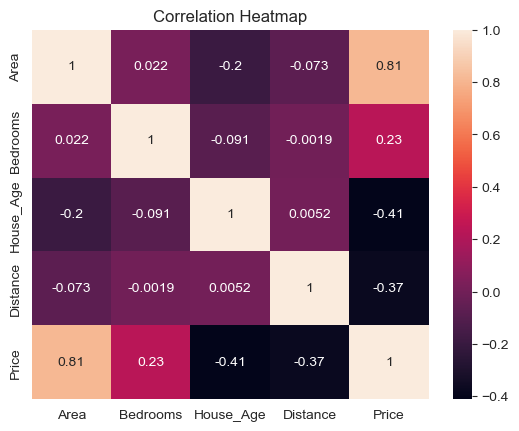

In [4]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.savefig('../outputs/plots/heatmap.png')
plt.show()

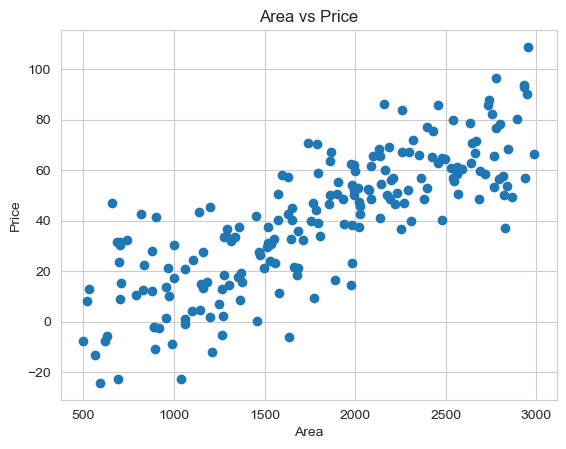

In [5]:
plt.figure()
plt.scatter(df["Area"], df["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.savefig('../outputs/plots/area_vs_price.png')
plt.show()

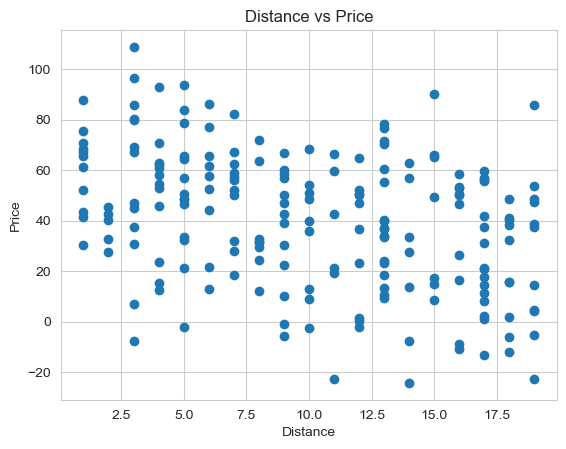

In [6]:
plt.figure()
plt.scatter(df["Distance"], df["Price"])
plt.xlabel("Distance")
plt.ylabel("Price")
plt.title("Distance vs Price")
plt.savefig('../outputs/plots/distance_vs_price.png')
plt.show()

In [7]:
X = df[["Area", "Bedrooms", "House_Age", "Distance"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Absolute Error: 9.823156890162759
R2 Score: 0.8085090773411429


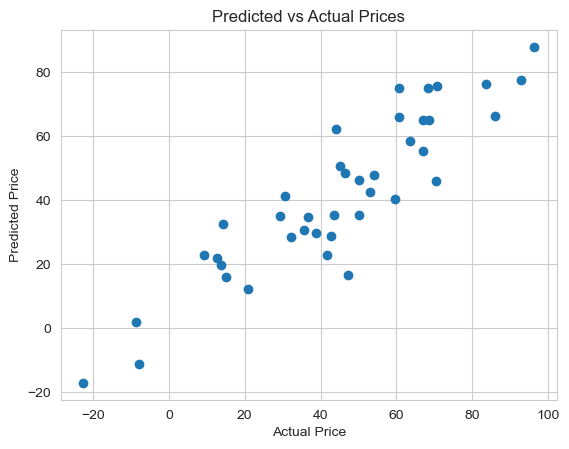

In [10]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.savefig('../outputs/plots/predicted_vs_actual.png')
plt.show()

In [11]:
joblib.dump(model, '../outputs/model.pkl')

['../outputs/model.pkl']

In [ ]:
def predict_price(area, bedrooms, age, distance):
    user_df = pd.DataFrame(
        [[area, bedrooms, age, distance]],
        columns=["Area", "Bedrooms", "House_Age", "Distance"]
    )
    return model.predict(user_df)[0]

area = float(input("Enter Area (sq ft): "))
bedrooms = int(input("Enter Number of Bedrooms: "))
house_age = int(input("Enter House Age (years): "))
distance = float(input("Enter Distance from city (km): "))

print("Predicted Price (Lakhs):", round(predict_price(area, bedrooms, house_age, distance), 2))